# Part 1 — Corruption Pipeline

Generates **unanswerable** question variants from DocVQA by corrupting original questions, then verifies them with a Vision LLM judge (LLM-as-a-Judge).

Three corruption types:
- **NLP Entity** — replace a named entity / number in the question with a different one
- **Element** — replace a document-element reference (table → figure, chart → graph …)
- **Layout** — replace a spatial reference (top → bottom, left → right …)

In [1]:
CONFIG = {
    # ---- dataset ----
    "dataset_name": "VLR-CVC/DocVQA-2026",  # public DocVQA subset, no auth needed
    "split": "val",  # "test" split has hidden answers (all NULL) — use validation
    "num_samples": 300,
    # ---- corruption ----
    "corruption_distribution": {"nlp_entity": 0.4, "element": 0.3, "layout": 0.3},
    # ---- judge model ----
    # Must be DIFFERENT from the models benchmarked in Part 2 to avoid circular evaluation.
    # Qwen2.5-VL is specialized for document understanding → reliable judge.
    "judge_model": "Qwen/Qwen2.5-VL-7B-Instruct",
    # ---- output ----
    "data_dir": "data",
    # ---- misc ----
    "seed": 42,
    "window_size": 1,   # pages per window; increase for multi-page doc support
}

In [2]:
import os
import json
import re
import random
import subprocess
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from PIL import Image
from datasets import load_dataset

# Raise PIL's decompression-bomb limit — DocVQA contains very high-res scans
Image.MAX_IMAGE_PIXELS = None

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
Path(CONFIG["data_dir"]).mkdir(parents=True, exist_ok=True)

print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  Device count : {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name}  {props.total_memory / 1e9:.1f} GB")

/davinci-1/home/abuonfiglio/MasterPoliTO/GenAI/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available : True
  Device count : 4
  GPU 0: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 1: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 2: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 3: NVIDIA A100-SXM4-40GB  42.4 GB


## Load dataset

Loading VLR-CVC/DocVQA-2026 …
Loaded 25 samples.

Columns : ['doc_id', 'doc_category', 'preview', 'document', 'questions', 'answers']
Types   : {'doc_id': 'str', 'doc_category': 'str', 'preview': 'PngImageFile', 'document': 'list', 'questions': 'dict', 'answers': 'dict'}

Mapped  : question='questions'  answers='answers'  image='preview'

Raw questions dict : {'question_id': ['comics_1_q1'], 'question': ["How many times do people get in the head in Nyoka and the Witch Doctor's Madness?"]}
Raw answers  dict  : {'question_id': ['comics_1_q1'], 'answer': ['4']}

Example :
  Q : How many times do people get in the head in Nyoka and the Witch Doctor's Madness?
  A : 4


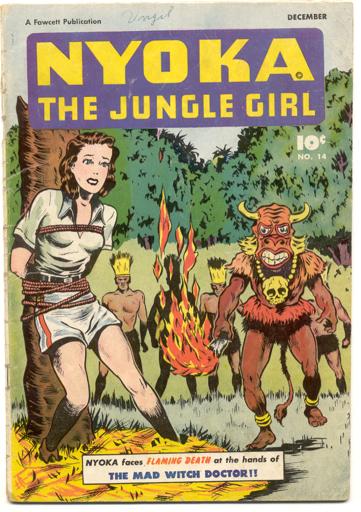

In [3]:
print(f"Loading {CONFIG['dataset_name']} …")
dataset = load_dataset(CONFIG["dataset_name"], split=CONFIG["split"])
n = min(CONFIG["num_samples"], len(dataset))
dataset = dataset.select(range(n))
print(f"Loaded {len(dataset)} samples.")

# Inspect actual structure before assuming column names
sample = dataset[0]
print(f"\nColumns : {dataset.column_names}")
print(f"Types   : { {k: type(v).__name__ for k, v in sample.items()} }")

# Map to canonical names used throughout the notebook
_QUESTION_COL = next(c for c in dataset.column_names if c.lower() in ["question", "query", "questions"])
_ANSWERS_COL  = next(c for c in dataset.column_names if c.lower() in ["answers", "answer"])
_IMAGE_COL    = next(c for c in dataset.column_names if c.lower() in ["image", "img", "preview"])
print(f"\nMapped  : question='{_QUESTION_COL}'  answers='{_ANSWERS_COL}'  image='{_IMAGE_COL}'")

sample_q = sample[_QUESTION_COL]
sample_a = sample[_ANSWERS_COL]

# Debug: show the raw structure so we can see exact keys and values
print(f"\nRaw questions dict : {repr(sample_q)}")
print(f"Raw answers  dict  : {repr(sample_a)}")

# Extract the first question text and answer text from whatever structure the dict has
def _first_text(d, text_keys):
    """Given a columnar dict, return the first value under any of text_keys, or the first value overall."""
    if isinstance(d, dict):
        for k in text_keys:
            if k in d:
                v = d[k]
                return v[0] if isinstance(v, list) else v
        # Fallback: first value (may still be an ID list — caller will see this in debug output)
        v = next(iter(d.values()))
        return v[0] if isinstance(v, list) else v
    if isinstance(d, list):
        return d[0] if d else None
    return d

q_display = _first_text(sample_q, ["question", "query", "text"])
a_display = _first_text(sample_a, ["answer", "answers", "text"])

print(f"\nExample :")
print(f"  Q : {q_display}")
print(f"  A : {a_display}")
sample[_IMAGE_COL]   # display first document image inline

## Corruption resources

In [4]:
# -- spaCy for NER-based entity corruption --
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
except (ImportError, OSError):
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    import spacy
    nlp = spacy.load("en_core_web_sm")
print(f"spaCy {spacy.__version__} ready.")

# Replacement pools by spaCy entity label
ENTITY_POOLS = {
    "DATE":     ["January 2020", "March 2019", "December 2021", "Q3 2022",
                 "FY2023", "2018", "2024", "April 2021", "June 2017"],
    "CARDINAL": ["42", "157", "3200", "12", "88", "1000", "250", "7", "500"],
    "MONEY":    ["$500", "$1,200", "€2,500", "$75,000", "£300", "$10 million"],
    "ORG":      ["Acme Corp", "Global Industries", "TechSolutions Inc.",
                 "National Bureau", "Allied Group", "Pacific Holdings"],
    "PERSON":   ["John Smith", "Maria Garcia", "Robert Johnson", "Emily Chen", "David Miller"],
    "GPE":      ["New York", "London", "Tokyo", "Berlin", "Sydney", "Chicago", "Paris"],
    "PERCENT":  ["15%", "42%", "3.5%", "99%", "0.1%", "67.8%", "28%"],
    "ORDINAL":  ["first", "second", "third", "fourth", "fifth"],
    "LOC":      ["North America", "Eastern Europe", "the Pacific", "Southeast Asia"],
    "TIME":     ["9:00 AM", "3:30 PM", "midnight", "noon"],
}

# Document element substitutions
ELEMENT_REPLACEMENTS = {
    "table":    ["figure", "chart", "graph", "appendix", "footnote"],
    "figure":   ["table", "chart", "diagram", "graph"],
    "chart":    ["table", "figure", "graph", "diagram"],
    "graph":    ["table", "figure", "chart", "diagram"],
    "footnote": ["table", "figure", "appendix", "section"],
    "section":  ["table", "figure", "appendix", "chapter"],
    "appendix": ["table", "figure", "section", "footnote"],
    "diagram":  ["table", "figure", "chart", "graph"],
}

# Layout / spatial reference substitutions
LAYOUT_REPLACEMENTS = {
    "top":       ["bottom", "middle"],
    "bottom":    ["top", "middle"],
    "left":      ["right", "center"],
    "right":     ["left", "center"],
    "upper":     ["lower", "middle"],
    "lower":     ["upper", "middle"],
    "first":     ["last", "second"],
    "last":      ["first", "second"],
    "header":    ["footer", "body"],
    "footer":    ["header", "body"],
    "above":     ["below", "beside"],
    "below":     ["above", "beside"],
    "beginning": ["end", "middle"],
    "end":       ["beginning", "middle"],
}


def pick_replacement(pool, original):
    candidates = [x for x in pool if x.lower() != original.lower()]
    return random.choice(candidates) if candidates else None

spaCy 3.8.14 ready.


## Corruption functions

In [5]:
def corrupt_nlp_entity(question):
    """Replace a spaCy-detected entity or inline number with a different value."""
    doc = nlp(question)
    candidates = [(e.text, e.label_) for e in doc.ents if e.label_ in ENTITY_POOLS]

    if candidates:
        orig_text, label = random.choice(candidates)
        replacement = pick_replacement(ENTITY_POOLS[label], orig_text)
        if replacement:
            corrupted = question.replace(orig_text, replacement, 1)
            if corrupted != question:
                return {"question": corrupted,
                        "detail": {"original": orig_text, "replacement": replacement,
                                   "entity_type": label}}

    # Fallback: replace an inline integer (e.g. "Table 1" → "Table 4")
    m = re.search(r'\b(\d+)\b', question)
    if m:
        orig_num = m.group(1)
        pool = [str(i) for i in range(1, 10) if str(i) != orig_num]
        replacement = random.choice(pool)
        corrupted = question[:m.start()] + replacement + question[m.end():]
        return {"question": corrupted,
                "detail": {"original": orig_num, "replacement": replacement,
                           "entity_type": "CARDINAL"}}
    return None


def corrupt_element(question):
    """Replace a document-element keyword (table, figure, …) with a different one."""
    q_lower = question.lower()
    for element, replacements in ELEMENT_REPLACEMENTS.items():
        if re.search(r'\b' + re.escape(element) + r'\b', q_lower):
            replacement = random.choice(replacements)
            corrupted = re.sub(r'\b' + re.escape(element) + r'\b',
                               replacement, question, count=1, flags=re.IGNORECASE)
            if corrupted.lower() != question.lower():
                return {"question": corrupted,
                        "detail": {"original": element, "replacement": replacement}}
    return None


def corrupt_layout(question):
    """Replace a spatial / layout keyword (top, left, first, …) with a different one."""
    q_lower = question.lower()
    for term, replacements in LAYOUT_REPLACEMENTS.items():
        if re.search(r'\b' + re.escape(term) + r'\b', q_lower):
            replacement = random.choice(replacements)
            corrupted = re.sub(r'\b' + re.escape(term) + r'\b',
                               replacement, question, count=1, flags=re.IGNORECASE)
            if corrupted.lower() != question.lower():
                return {"question": corrupted,
                        "detail": {"original": term, "replacement": replacement}}
    return None


CORRUPTION_FNS = {
    "nlp_entity": corrupt_nlp_entity,
    "element":    corrupt_element,
    "layout":     corrupt_layout,
}
FALLBACK_ORDER = list(CORRUPTION_FNS.keys())


def apply_corruption(question, preferred_type):
    """Try preferred corruption type; fall back to others if it produces no match."""
    result = CORRUPTION_FNS[preferred_type](question)
    if result is not None:
        return result, preferred_type
    for ctype in FALLBACK_ORDER:
        if ctype == preferred_type:
            continue
        result = CORRUPTION_FNS[ctype](question)
        if result is not None:
            return result, ctype
    return None, None

## Generate corrupted samples

In [6]:
candidates_path = Path(CONFIG["data_dir"]) / "corrupted_candidates.json"

# Always define these so downstream cells work regardless of which branch runs
corruption_types = list(CONFIG["corruption_distribution"].keys())
weights = list(CONFIG["corruption_distribution"].values())

def _load_candidates_if_valid(path, dataset_size):
    """Load cached candidates only if all stored idx values are within the current dataset."""
    if not path.exists():
        return None
    with open(path) as f:
        data = json.load(f)
    if not data:
        return None
    max_idx = max(d["idx"] for d in data)
    if max_idx >= dataset_size:
        print(f"Cache invalidata: idx {max_idx} >= dataset size {dataset_size} — rigenero.")
        path.unlink()
        return None
    return data

corrupted_data = _load_candidates_if_valid(candidates_path, len(dataset))

if corrupted_data is not None:
    print(f"Candidati già salvati in {candidates_path} — salto la corruzione.")
    print(f"Caricati {len(corrupted_data)} candidati.")
    print("Distribuzione:", dict(Counter(d["corruption_type"] for d in corrupted_data)))
else:
    corrupted_data = []
    skipped = 0
    total_questions = 0

    for idx in tqdm(range(len(dataset)), desc="Corrupting"):
        questions_raw = dataset[idx][_QUESTION_COL]
        answers_raw   = dataset[idx][_ANSWERS_COL]

        # Columnar dict: {'question_id': [...], 'question': [...]} — used by DocVQA-2026
        if isinstance(questions_raw, dict) and "question" in questions_raw:
            qs   = questions_raw["question"]
            qids = questions_raw.get("question_id", [None] * len(qs))
            ans_list = answers_raw.get("answer", []) if isinstance(answers_raw, dict) else []
            qa_pairs = [
                (qids[i], qs[i], [ans_list[i]] if i < len(ans_list) else [])
                for i in range(len(qs))
            ]
        # Legacy dict: {question_id: question_text}
        elif isinstance(questions_raw, dict):
            qa_pairs = [
                (qid, q, answers_raw.get(qid, []) if isinstance(answers_raw, dict) else answers_raw)
                for qid, q in questions_raw.items()
            ]
        elif isinstance(questions_raw, list):
            qa_pairs = [(None, q, answers_raw) for q in questions_raw]
        else:
            qa_pairs = [(None, questions_raw, answers_raw)]

        total_questions += len(qa_pairs)

        for qid, question, answers in qa_pairs:
            if not isinstance(question, str):
                skipped += 1
                continue

            # Skip questions with no real ground-truth answer.
            # The test split uses "NULL" as a placeholder for hidden answers;
            # corrupting an already-unanswerable question would trivially pass the judge.
            if not answers or all(str(a).strip().upper() in ("NULL", "NONE", "") for a in answers):
                skipped += 1
                continue

            preferred = random.choices(corruption_types, weights=weights, k=1)[0]
            result, used_type = apply_corruption(question, preferred)

            if result is None:
                skipped += 1
                continue

            corrupted_data.append({
                "idx":                idx,
                "qid":                qid,
                "original_question":  question,
                "original_answers":   answers,
                "corrupted_question": result["question"],
                "corruption_type":    used_type,
                "corruption_detail":  result["detail"],
                "judge_verdict":      None,
            })

    print(f"Documenti   : {len(dataset)}")
    print(f"Domande tot : {total_questions}")
    print(f"Corrotti    : {len(corrupted_data)}  (saltati: {skipped})")
    print("Distribuzione:", dict(Counter(d["corruption_type"] for d in corrupted_data)))

    with open(candidates_path, "w") as f:
        json.dump(corrupted_data, f, indent=2)
    print(f"Candidati salvati → {candidates_path}")

Corrupting: 100%|██████████| 25/25 [00:53<00:00,  2.13s/it]

Documenti   : 25
Domande tot : 80
Corrotti    : 59  (saltati: 21)
Distribuzione: {'nlp_entity': 45, 'layout': 11, 'element': 3}
Candidati salvati → data/corrupted_candidates.json


In [7]:
print("=== One example per corruption type ===\n")
for ctype in corruption_types:
    example = next((d for d in corrupted_data if d["corruption_type"] == ctype), None)
    if example is None:
        print(f"[{ctype}]  — no examples found\n")
        continue
    det = example["corruption_detail"]
    print(f"[{ctype}]")
    print(f"  Original  : {example['original_question']}")
    print(f"  Corrupted : {example['corrupted_question']}")
    print(f"  Change    : '{det['original']}' → '{det['replacement']}'")
    print()

=== One example per corruption type ===

[nlp_entity]
  Original  : How many times do people get in the head in Nyoka and the Witch Doctor's Madness?
  Corrupted : How many times do people get in the head in Chicago and the Witch Doctor's Madness?
  Change    : 'Nyoka' → 'Chicago'

[element]
  Original  : In the figure with peaks (that seem like frequency peaks). There is a row with a clearly visible last peak. What is the word in the figure caption that is directly below that peak (the closest one to it)?
  Corrupted : In the graph with peaks (that seem like frequency peaks). There is a row with a clearly visible last peak. What is the word in the figure caption that is directly below that peak (the closest one to it)?
  Change    : 'figure' → 'graph'

[layout]
  Original  : What was the last state that the man murdered in front of the diner visited?
  Corrupted : What was the first state that the man murdered in front of the diner visited?
  Change    : 'last' → 'first'



## LLM-as-a-Judge quality verification

Load the Vision LLM on the HPC GPUs and ask it whether each corrupted question is answerable from the document.
Only samples where the model says **UNANSWERABLE** are kept in the final dataset.

In [8]:
from transformers import AutoProcessor

try:
    from transformers import AutoModelForImageTextToText
    ModelClass = AutoModelForImageTextToText
except ImportError:                          # transformers < 4.49
    from transformers import AutoModelForCausalLM
    ModelClass = AutoModelForCausalLM

print(f"Loading judge model: {CONFIG['judge_model']} …")
processor = AutoProcessor.from_pretrained(CONFIG["judge_model"])
judge_model = ModelClass.from_pretrained(
    CONFIG["judge_model"],
    device_map="auto",          # spreads across all available GPUs automatically
    dtype=torch.bfloat16,
)
judge_model.eval()
print("Ready.")
print("Device map:", judge_model.hf_device_map)

Loading judge model: Qwen/Qwen2.5-VL-7B-Instruct …


Loading weights: 100%|██████████| 729/729 [00:07<00:00, 97.52it/s] 


Ready.
Device map: {'model.visual': 0, 'model.language_model.embed_tokens': 0, 'model.language_model.layers.0': 0, 'model.language_model.layers.1': 0, 'model.language_model.layers.2': 1, 'model.language_model.layers.3': 1, 'model.language_model.layers.4': 1, 'model.language_model.layers.5': 1, 'model.language_model.layers.6': 1, 'model.language_model.layers.7': 1, 'model.language_model.layers.8': 1, 'model.language_model.layers.9': 1, 'model.language_model.layers.10': 1, 'model.language_model.layers.11': 1, 'model.language_model.layers.12': 2, 'model.language_model.layers.13': 2, 'model.language_model.layers.14': 2, 'model.language_model.layers.15': 2, 'model.language_model.layers.16': 2, 'model.language_model.layers.17': 2, 'model.language_model.layers.18': 2, 'model.language_model.layers.19': 2, 'model.language_model.layers.20': 2, 'model.language_model.layers.21': 2, 'model.language_model.layers.22': 3, 'model.language_model.layers.23': 3, 'model.language_model.layers.24': 3, 'model

In [9]:
JUDGE_PROMPT = (
    "You are a quality control system for a document question answering benchmark.\n"
    "Examine the document image carefully.\n"
    "Can the following question be answered solely from the content visible in the document?\n\n"
    "Question: {question}\n\n"
    "Reply with one word only: ANSWERABLE or UNANSWERABLE"
)

_input_device = next(judge_model.parameters()).device
_MAX_SIDE = 2048  # Qwen2.5-VL internal resolution cap; anything larger is downsampled anyway


def _prepare_image(img: Image.Image) -> Image.Image:
    """Convert to RGB and cap the longest side to _MAX_SIDE to avoid OOM on huge scans."""
    img = img.convert("RGB")
    w, h = img.size
    if max(w, h) > _MAX_SIDE:
        scale = _MAX_SIDE / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    return img


def judge_unanswerability(pil_image: Image.Image, question: str) -> str:
    pil_image = _prepare_image(pil_image)
    messages = [{"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": JUDGE_PROMPT.format(question=question)},
    ]}]
    text = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(
        text=text, images=[pil_image], return_tensors="pt"
    ).to(_input_device)

    with torch.no_grad():
        out = judge_model.generate(**inputs, max_new_tokens=10, do_sample=False)

    input_len = inputs["input_ids"].shape[1]
    response = processor.decode(
        out[0][input_len:], skip_special_tokens=True
    ).strip().upper()
    return "UNANSWERABLE" if "UNANSWERABLE" in response else "ANSWERABLE"

In [10]:
verified_data = []
rejected = 0

for item in tqdm(corrupted_data, desc="Judging"):
    img = dataset[item["idx"]][_IMAGE_COL]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img).convert("RGB")

    verdict = judge_unanswerability(img, item["corrupted_question"])
    item["judge_verdict"] = verdict

    if verdict == "UNANSWERABLE":
        verified_data.append(item)
    else:
        rejected += 1

print(f"\nPassati (unanswerable) : {len(verified_data)}")
print(f"Rigettati (answerable) : {rejected}")
print(f"Pass rate              : {len(verified_data) / max(len(corrupted_data), 1):.1%}")

Judging: 100%|██████████| 59/59 [01:08<00:00,  1.16s/it]


Passati (unanswerable) : 59
Rigettati (answerable) : 0
Pass rate              : 100.0%


## Statistics & examples

In [11]:
# Use in-memory verified_data if available; fall back to the saved JSON otherwise
# (covers the case where the kernel was restarted after a completed run)
if 'verified_data' in dir() and verified_data:
    _data = verified_data
else:
    dataset_path = Path(CONFIG["data_dir"]) / "corrupted_dataset.json"
    print(f"verified_data not in memory — loading from {dataset_path}")
    with open(dataset_path) as f:
        _data = json.load(f)

df = pd.DataFrame(_data)
print(f"=== Final Dataset: {len(df)} samples ===\n")
print("By corruption type:")
print(df["corruption_type"].value_counts().to_string())

print("\n--- Sample corruptions ---")
for ctype in df["corruption_type"].unique():
    row = df[df["corruption_type"] == ctype].iloc[0]
    print(f"\n[{ctype}]")
    print(f"  Original  : {row['original_question']}")
    print(f"  Corrupted : {row['corrupted_question']}")
    print(f"  Change    : {row['corruption_detail']}")
    print(f"  Orig. ans : {row['original_answers']}")

=== Final Dataset: 59 samples ===

By corruption type:
corruption_type
nlp_entity    45
layout        11
element        3

--- Sample corruptions ---

[nlp_entity]
  Original  : How many times do people get in the head in Nyoka and the Witch Doctor's Madness?
  Corrupted : How many times do people get in the head in Chicago and the Witch Doctor's Madness?
  Change    : {'original': 'Nyoka', 'replacement': 'Chicago', 'entity_type': 'GPE'}
  Orig. ans : ['4']

[layout]
  Original  : What was the last state that the man murdered in front of the diner visited?
  Corrupted : What was the first state that the man murdered in front of the diner visited?
  Change    : {'original': 'last', 'replacement': 'first'}
  Orig. ans : ['Indiana']

[element]
  Original  : In the figure with peaks (that seem like frequency peaks). There is a row with a clearly visible last peak. What is the word in the figure caption that is directly below that peak (the closest one to it)?
  Corrupted : In the graph wit

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

def _get_img(idx):
    img = dataset[idx][_IMAGE_COL]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img).convert("RGB")
    return img

def _wrap(text, width=36):
    return "\n".join(textwrap.wrap(str(text), width))

N = 5

# ── 1. INPUT DATASET ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, N, figsize=(20, 8),
                         gridspec_kw={"height_ratios": [4, 1.2]})
fig.suptitle("Input Dataset — head(5)", fontsize=13, fontweight="bold")

for col in range(N):
    raw = dataset[col]
    img = _get_img(col)

    q_raw, a_raw = raw[_QUESTION_COL], raw[_ANSWERS_COL]
    if isinstance(q_raw, dict) and "question" in q_raw:
        q_text = q_raw["question"][0]
        a_text = (a_raw["answer"][0] if isinstance(a_raw, dict) and "answer" in a_raw
                  else str(a_raw))
    elif isinstance(q_raw, list):
        q_text, a_text = q_raw[0], (a_raw[0] if isinstance(a_raw, list) else str(a_raw))
    else:
        q_text, a_text = str(q_raw), str(a_raw)

    ax_img = axes[0, col]
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title(f"Doc #{col}", fontsize=9)

    ax_txt = axes[1, col]
    ax_txt.axis("off")
    ax_txt.text(0.5, 0.95,
                f"Q: {_wrap(q_text, 34)}\nA: {_wrap(a_text, 34)}",
                transform=ax_txt.transAxes, fontsize=6.8,
                va="top", ha="center",
                bbox=dict(boxstyle="round,pad=0.3", fc="#f0f4ff", ec="#aaaacc", lw=0.7))

plt.tight_layout()
plt.show()

# ── 2. CORRUPTED DATASET ────────────────────────────────────────────────────
_src = verified_data if (verified_data if 'verified_data' in dir() else []) else corrupted_data
head5 = _src[:N]

TYPE_COLORS = {"nlp_entity": "#ffe0b2", "element": "#c8e6c9", "layout": "#b3e5fc"}

fig2, axes2 = plt.subplots(2, N, figsize=(20, 9),
                            gridspec_kw={"height_ratios": [3, 2.2]})
fig2.suptitle("Corrupted Dataset — head(5)", fontsize=13, fontweight="bold")

for col, item in enumerate(head5):
    img = _get_img(item["idx"])
    ctype = item["corruption_type"]
    det = item["corruption_detail"]

    ax_img = axes2[0, col]
    ax_img.imshow(img)
    ax_img.axis("off")
    ax_img.set_title(f"Doc #{item['idx']}  [{ctype}]", fontsize=8, color="navy")

    ax_txt = axes2[1, col]
    ax_txt.axis("off")
    change = f"\"{det['original']}\" → \"{det['replacement']}\""
    info = (
        f"ORIG:\n{_wrap(item['original_question'], 33)}\n\n"
        f"CORRUPTED:\n{_wrap(item['corrupted_question'], 33)}\n\n"
        f"change: {change}"
    )
    ax_txt.text(0.5, 0.98, info, transform=ax_txt.transAxes,
                fontsize=6.3, va="top", ha="center",
                bbox=dict(boxstyle="round,pad=0.4",
                          fc=TYPE_COLORS.get(ctype, "#f9f9f9"),
                          ec="#888888", lw=0.7))

patches = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLORS.items()]
fig2.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
            title="Corruption type", bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


## Save final dataset

In [12]:
out_dir      = Path(CONFIG["data_dir"])
img_dir      = out_dir / "images"
img_dir.mkdir(exist_ok=True)
dataset_path = out_dir / "corrupted_dataset.json"

if dataset_path.exists():
    print(f"File già presenti in {dataset_path} — salto il salvataggio.")
else:
    for item in tqdm(verified_data, desc="Saving images"):
        img_path = img_dir / f"{item['idx']:04d}.jpg"
        if not img_path.exists():
            img = dataset[item["idx"]][_IMAGE_COL]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(img).convert("RGB")
            img.save(img_path, quality=85)
        item["image_path"] = str(img_path)

    with open(dataset_path, "w") as f:
        json.dump(verified_data, f, indent=2)

    print(f"Salvati {len(verified_data)} campioni → {dataset_path}")
    print(f"Immagini                              → {img_dir}")

Saving images: 100%|██████████| 59/59 [00:19<00:00,  2.99it/s]

Salvati 59 campioni → data/corrupted_dataset.json
Immagini                              → data/images
